# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import glob
import graphical_sampling as gs
import pandas as pd
import numpy as np
import itertools
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities

/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "XPC_SERVICE_NAME" redefined by R and overriding existing variable. Current: "application.com.jetbrains.pycharm.1003326.4172874", R: "0"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpcsFW9A", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//Rtmp1DvNrx"
  warnings.warn(


# Loading and Determining Population

In [3]:
DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    coords = data[:, :2]
    probs  = data[:, -1]

    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())
print(probs_dict.keys())
print(probs_dict['random'].keys())

dict_keys(['swiss', 'cluster', 'meuse', 'random', 'grid'])
dict_keys(['swiss', 'cluster', 'meuse', 'random', 'grid'])
dict_keys(['equal', 'unequal'])


In [37]:
N = 100
n = 16
pop_str = 'grid'
prob_str = 'equal'
coords = coords_dict[pop_str]
probs = probs_dict[pop_str][prob_str]
modified_probs = inclusion_probabilities(probs, n=n)
pop = gs.Population(coords, modified_probs)

In [10]:
coords = np.loadtxt("populations/AggregatedPop1027_2d.csv", delimiter=",", skiprows=0)
rng = gs.random.rng()
n = 20
probs = rng.equal_probabilities(n, coords.shape[0])
pop = gs.Population(coords, probs)

# Building Initial Designs

In [13]:
orders = [
    # "lexico-yx",
    # "lexico-xy",
    # "random",
    # "angle_0",
    # "distance_0",
    "projection",
    # "center",
    # "spiral",
    # "max",
    # "snake",
    # "hilbert",
]
n_zones_sweep = [(2, 2), (3, 3)]
n_zones_cluster = [4, 6]
combinations = list(itertools.product(['sweep'], n_zones_sweep, orders, orders)) + list(itertools.product(['cluster'], n_zones_cluster, orders, orders))

In [14]:
initial_designs = []
num_trials = 2
for zone_builder, n_zones, units_order, zones_order in tqdm(combinations, desc="Generating initial designs", total=len(combinations), unit="orders"):
    best = None
    best_score = np.inf
    for _ in range(num_trials):
        ks = gs.sampling.KMeansSampler(
            population=pop,
            n=n,
            n_zones=n_zones,
            zone_builder=zone_builder,
            units_order=units_order,
            zones_order=zones_order,
            split_size=0.001
        )
        if ks.expected_moran_score() < best_score:
            best = ks
            best_score = ks.expected_moran_score()

    initial_designs.append(gs.NewDesign(best))

Generating initial designs:   0%|          | 0/4 [00:00<?, ?orders/s]/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//Rtmp1DvNrx", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpNc63Ww"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//Rtmp1DvNrx", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//Rtmpxnxgzl"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" re

# Run

In [15]:
moran_criteria = gs.criteria.MoranCriteria()

In [16]:
initial_criteria_value = np.array([moran_criteria(design) for design in initial_designs])
best_design = initial_designs[np.argmax(initial_criteria_value)]
best_criteria_value = np.min(initial_criteria_value)
best_criteria_value

np.float64(-0.20677487931966287)

In [19]:
astar = gs.search.AStar(
    initial_designs,
    moran_criteria
)

best initial criteria value -0.20677487931966287


In [21]:
astar = gs.search.AStar(
    [astar.best_design],
    moran_criteria
)

best initial criteria value -0.2069625103212701


In [22]:
astar.run(
    max_iterations = 1000,
    num_new_nodes = 20,
    max_open_set_size = 1000,

    n_clusters_to_change_order_zone = 1,
    n_changes_in_order_of_zones = 1,

    n_clusters_to_change_order_units = 1,
    n_zones_to_change_order_units = 1,
    n_changes_in_order_of_units = 1,

    n_jobs=-1
)


parent node: -0.2069625103212701


/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//Rtmp1DvNrx", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpgQos0S"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//Rtmp1DvNrx", R: "/var/folders/tw/x1njhbdj7q19p65g47mw5dqm0000gn/T//RtmpSNIWkU"
  warnings.warn(
/Users/mehdi/Documents/Projects/graphical_sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders

child node: -0.207397609558796

New best criteria value: -0.207397609558796
child node: -0.20689629693792383
child node: -0.20161138725162836
child node: -0.19895950076480107
child node: -0.20560392567301933
child node: -0.2068010532099376
child node: -0.20481526206763057
child node: -0.2057900768442232
child node: -0.19143625731537162
child node: -0.20702006891121094
child node: -0.20638890835537868
child node: -0.20696247127780937
child node: -0.20799985156451714

New best criteria value: -0.20799985156451714
child node: -0.20727785991066006
child node: -0.20371280668104774
child node: -0.20800166878851972

New best criteria value: -0.20800166878851972
child node: -0.213745478284224

New best criteria value: -0.213745478284224
child node: -0.21695930060818308

New best criteria value: -0.21695930060818308
child node: -0.2006172878468973
child node: -0.20669731078774778

parent node: -0.21695930060818308
child node: -0.2171248333674342

New best criteria value: -0.2171248333674342
chi

KeyboardInterrupt: 

In [23]:
astar.best_criteria_value

-0.24898385729914374

In [24]:
astar.best_design.kmeans.all_samples.shape

(332, 20)

In [25]:
np.sum(astar.best_design.kmeans.all_samples_probs)

np.float64(1.0)

In [27]:
np.mean(np.abs(astar.best_design.kmeans.fips - probs))

np.float64(0.0006219611368455774)

In [28]:
astar.best_design.kmeans.fips

array([0.0194742, 0.0194742, 0.0194742, ..., 0.0194742, 0.0194742,
       0.0194742], shape=(1027,))

In [29]:
np.sqrt(astar.best_design.kmeans.var_moran_score())

np.float64(0.051920976433342605)

In [76]:
astar.best_design.kmeans.moran_scores

array([-0.50854305, -0.54293679, -0.65922451, -0.64147852, -0.57183288,
       -0.58202557, -0.56105458, -0.45920847, -0.5618256 , -0.59335246,
       -0.54823247, -0.589926  , -0.53048317, -0.56353487, -0.54957034,
       -0.55135462, -0.63054903, -0.62841727, -0.59349016, -0.71381491,
       -0.66701377, -0.57776011, -0.55605104, -0.58317301, -0.63929135,
       -0.48359111, -0.61539171, -0.51574499, -0.55439157, -0.58472678,
       -0.71808128, -0.6459911 , -0.52057374, -0.59028964, -0.57343073,
       -0.61691472, -0.70571138, -0.56483565, -0.64364067, -0.60274384,
       -0.62059921, -0.57920348, -0.71291035, -0.54268658, -0.63107332,
       -0.52090799, -0.65304167, -0.68789819, -0.45113366, -0.39102337])

In [34]:
astar.best_design.kmeans.score_summary_df()

,expected,std
measure,,
density,0.061670,0.053995
moran,-0.248984,0.051921
local_balance,0.124720,0.036959
voronoi,0.105414,0.061637


In [30]:
def info(kmeans):
    mean = round(float(kmeans.expected_moran_score()), 2)
    moran_scores = astar.best_design.kmeans.moran_scores
    median = round(float(np.median(moran_scores)), 2)
    sd = round(float(np.sqrt(kmeans.var_moran_score())), 2)
    min_ = round(float(np.min(moran_scores)), 2)
    max_ = round(float(np.max(moran_scores)), 2)
    return mean, median, sd, min_, max_

In [31]:
info(astar.best_design.kmeans)

(-0.25, -0.25, 0.05, -0.4, -0.14)

<Axes: xlabel='X', ylabel='Y'>

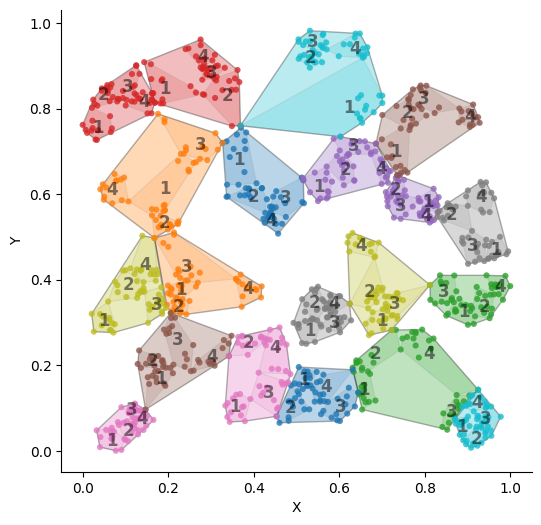

In [32]:
gs.plot(pop, astar.best_design.kmeans.clusters, connect_points=False)